In [1]:
import simpy
import matplotlib.pyplot as plt

In [2]:
import models

def run_simulation(lambda_rate, mu_rate, sim_time):
    env = simpy.Environment()
    stat = models.Stats()
    doctor = models.Doctor(env, stat, mu_rate)
    generator = models.PatientStreamGenerator(env, stat, doctor, lambda_rate)

    env.process(generator.start())
    env.run(until=sim_time)

    p_loss_exp = stat.rejected / stat.arrived if stat.arrived > 0 else 0
    utilization = stat.busy_time / sim_time if sim_time > 0 else 0

    print(f"Всего: {stat.arrived}, Обслужено: {stat.served}, Отказано: {stat.rejected}")

    return stat, p_loss_exp, utilization

def theoretical_m_m_1_0(lambda_rate, mu_rate):
    rho = lambda_rate / mu_rate
    p_loss = rho / (1 + rho)
    return p_loss

Lambda     P_отк (эксп)    P_отк (теория)  Загрузка  
Всего: 19840, Обслужено: 14182, Отказано: 5658
2.0        0.2852          0.2857          0.2833    
Всего: 40214, Обслужено: 22339, Отказано: 17875
4.0        0.4445          0.4444          0.4440    
Всего: 60083, Обслужено: 27306, Отказано: 32777
6.0        0.5455          0.5455          0.5448    
Всего: 80079, Обслужено: 30663, Отказано: 49416
8.0        0.6171          0.6154          0.6180    
Всего: 100221, Обслужено: 33365, Отказано: 66856
10.0       0.6671          0.6667          0.6669    


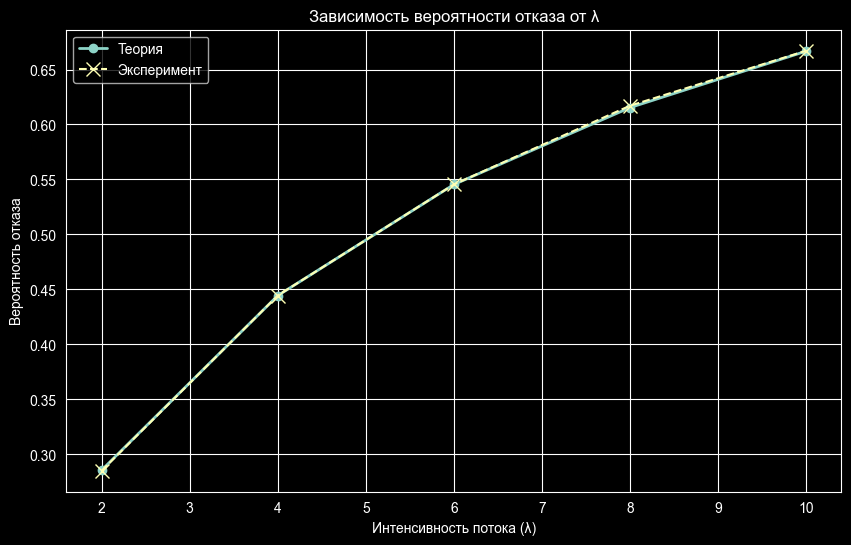

In [3]:
SIM_TIME = 10000
MU = 5.0
lambdas = [2.0, 4.0, 6.0, 8.0, 10.0]

results = []
theory_results = []

print(f"{'Lambda':<10} {'P_отк (эксп)':<15} {'P_отк (теория)':<15} {'Загрузка':<10}")

for LAMBDA in lambdas:
    stats, p_exp, util = run_simulation(LAMBDA, MU, SIM_TIME)
    p_theory = theoretical_m_m_1_0(LAMBDA, MU)
    results.append(p_exp)
    theory_results.append(p_theory)
    print(f"{LAMBDA:<10} {p_exp:<15.4f} {p_theory:<15.4f} {util:<10.4f}")

plt.figure(figsize=(10, 6))
plt.plot(lambdas, theory_results, 'o-', label='Теория', linewidth=2)
plt.plot(lambdas, results, 'x--', label='Эксперимент', markersize=10)
plt.xlabel('Интенсивность потока (λ)')
plt.ylabel('Вероятность отказа')
plt.title('Зависимость вероятности отказа от λ')
plt.grid(True)
plt.legend()
plt.savefig('lab1_graph.png')
plt.show()